## Finding Equilibrium point in case of Bayes' Theorem

Bayes' Theorem allows us to update priors as we see the evidence.

Let's use symbols to denote certain things:

    H: Hypothesis (Original Hypothesis)
    ¬H: Another hypothesis that is opposite of original hypothesis.
    E: Evidence (Original Evidence)
    ¬E: Any evidence that is counter of the original evidence.

Example of those symbols could be:
- H : A person has cancer.
- ¬H : A person doesn't have a cancer.
- E : Cancer test result was positive.
- ¬E : Cancer test result was negative.

Now, we use four different (known) conditional probabilities that help us to update our priors.

    P(E | H) = Probability of appearance of positive evidence if hypothesis is true.
    P(E | ¬H) = Probability of appearance of positive evidence if hypothesis is false.
    P(¬E | H) = Probability of appearance of negative evidence if hypothesis is true.
    P(¬E | ¬H) = Probability of appearance of negative evidence if hypothesis is false.

We must always start with some value of prior denoted by P(H) = Probability of hypothesis is false. This shouldn't be extreme (0 or 1).

Then bayes' theorem allows us to update our belief according to the evidence.

If Evidence was positive:

    P(H | E) = P(H, E)/P(E)

Where,

    P(H,E) = P(H) P(E | H)
    P(E) = P(H) P(E | H) + P(¬H) P(E | ¬H)

Or:

If evidence was negative:

    P(H | ¬E) = P(H, ¬E)/P(¬E)

Where,

    P(H,¬E) = P(H) P(¬E | H)
    P(¬E) = P(H) P(¬E | H) + P(¬H) P(¬E | ¬H)


But we realize that evidence itself is probabilistic. It is not guaranteed to be same every time if a hypothesis is true or false. 

The act of sampling large number of evidences that makes us to be able to arrive to a reasonable certainty level to a hypothesis.

If positive evidences are more correlated with hypothesis being true, given positive evidence we can be a bit more confident that hypothesis is true; we can raise its certainty level. Similar thing can be said for the negative hypothesis.

Special thing can happen if two 

In [1]:
import matplotlib.pyplot as plt 
import numpy as np

In [2]:
def apply_bayes_theorem(prior, likelihood, complementary_likelihood):
    """
    Apply Bayes' theorem to update the prior belief based on new evidence.

    Parameters:
        prior (float): P(H), The prior probability of the hypothesis. 
        likelihood (float): P(E|H), The likelihood of the evidence given the hypothesis. 
        complementary_likelihood (float): P(E|¬H), The likelihood of the evidence given the complementary hypothesis. 
    
    Returns:
    float: The posterior probability of the hypothesis given the evidence.

    ## Bayes Theorem
    Bayes' theorem formula:

        P(H|E) = (P(E|H) * P(H)) / P(E)
        P(E) = P(E|H) * P(H) + P(E|¬H) * P(¬H)
    
    Where:
        P(H|E) = Posterior probability of the hypothesis given the evidence.
        P(H) = Prior probability of the hypothesis.
        P(E|H) = Likelihood of the evidence given the hypothesis.
        P(E) = Marginal probability of the evidence.
        P(E|¬H) = Complementary likelihood of the evidence given the complementary hypothesis.
        P(¬H) = 1 - P(H)
    """
    # Calculate the marginal probability of the evidence
    evidence = (prior * likelihood) + ((1 - prior) * complementary_likelihood)
    
    # Calculate the posterior probability using Bayes' theorem
    return (prior * likelihood) / evidence

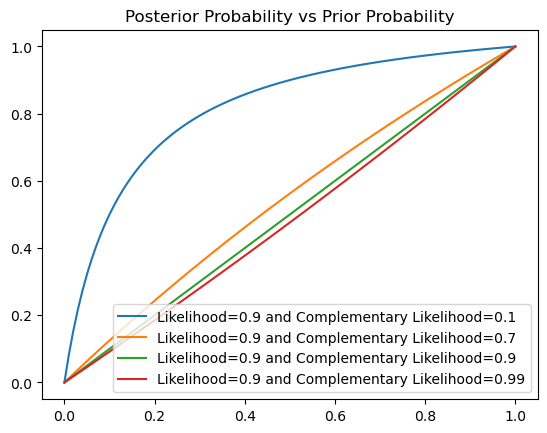

In [3]:
def generate_posteriori_vs_priori(likelihood = 0.97, complementary_likelihood = 0.10):
    """
    In Bayesian statistics, the posterior probability is calculated using Bayes' theorem.
    
    The prior probability is the initial probability of the hypothesis before observing the data.
    The posterior probability is the probability of a hypothesis given the observed data.
    The likelihood is the probability of observing the data given the hypothesis.
    The complementary likelihood is the probability of observing the data given the negation of the hypothesis.

    In notations:
    P(H|D) = (P(D|H) * P(H)) / P(D)
    
    where:
    P(H) = prior probability
    P(D|H) = likelihood
    P(D) = the total probability of observing the data
    P(H|D) = posterior probability

    And
    P(D) = P(D|H) * P(H) + P(D|¬H) * P(¬H)
    P(D|¬H) = complementary likelihood
    P(¬H) = 1 - P(H)
    """

    priories = np.linspace(0,1,101)
    posterioris = priories * likelihood / (priories * likelihood + (1-priories)*complementary_likelihood)
    return priories, posterioris

likelihood = 0.90
complementary_likelihood = 0.10
priories, posteriories = generate_posteriori_vs_priori(likelihood, complementary_likelihood)
plt.plot(priories,posteriories, label=f'Likelihood={likelihood} and Complementary Likelihood={complementary_likelihood}')
complementary_likelihood = 0.70
priories, posteriories = generate_posteriori_vs_priori(likelihood, complementary_likelihood)
plt.plot(priories,posteriories, label=f'Likelihood={likelihood} and Complementary Likelihood={complementary_likelihood}')
complementary_likelihood = 0.90
priories, posteriories = generate_posteriori_vs_priori(likelihood, complementary_likelihood)
plt.plot(priories,posteriories, label=f'Likelihood={likelihood} and Complementary Likelihood={complementary_likelihood}')
complementary_likelihood = 0.99
priories, posteriories = generate_posteriori_vs_priori(likelihood, complementary_likelihood)
plt.plot(priories,posteriories, label=f'Likelihood={likelihood} and Complementary Likelihood={complementary_likelihood}')
plt.title('Posterior Probability vs Prior Probability')
plt.legend()
plt.show()

# Conclusions
# 1. If prior probability is 0, the posterior probability is 0 regardless of the likelihood.
# 2. If prior probability is 1, the posterior probability is also 1 regardless of the likelihood.
#### You can't change a belief that is already 100% certain.

# 3. If likelihood is 0, the posterior probability is always 0.
# 4. If complementary likelihood is 0, the posterior probability is always 1.

# 5. If likelihood is greater than the complementary likelihood, the posterior probability will be greater than the prior probability.
# 6. If likelihood is same as the complementary likelihood, the posterior probability will be equal to the prior probability.
# 6. If likelihood is less as the complementary likelihood, the posterior probability will be less than the prior probability.

## Applying in a use case:

Let's consider a Medical Screening case for cancer where:

P(C) = probability of cancer \
P(T) = probability of positive test result

If a person actually has cancer, his test result would be positive 90% of the time. \
If a person doesn't have a cancer, his test result would be positive only 3% of the time.

So,

Likelihood = P(T | C) = 0.90 \
Complementary likelihood = P(T | ¬C) = 0.10

For a general population, assume only 1% have cancer (priori).

P(C) = 0.01

Now, let's found out if a person truly has cancer, how certain can we be if these distribution are correct.


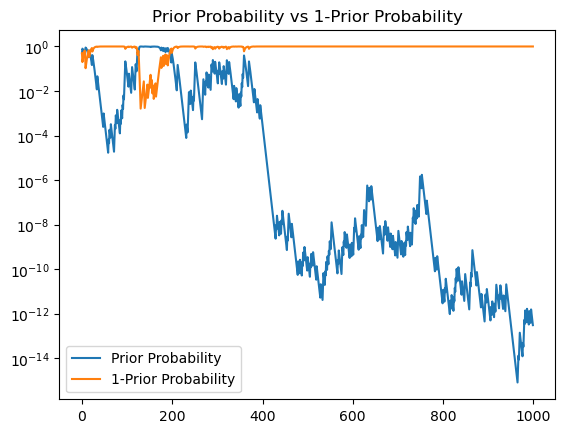

In [ ]:
def apply_bayes_theorem_successively(start_priori, 
                                     likelihood, 
                                     complementary_likelihood, 
                                     test_sampler,
                                     iterations):
    """
    Apply Bayes' theorem successively for a number of iterations.
    
    Parameters:
    start_priori (float): P(H), The initial prior probability.
    likelihood (float): P(E | H), The likelihood of the evidence given the hypothesis.
    complementary_likelihood (float): P(E | ¬H) The likelihood of the evidence given the complementary hypothesis.
    iterations (int): The number of iterations to apply Bayes' theorem.
    
    Returns:
    list, list, list: Lists of prior probabilities, posterior probabilities, and test results.
    """

    priors, posteriors, samples = [], [], []
    prior = start_priori
    for i in range(iterations):
        test_result = test_sampler()
        if test_result: # positive test result
            posterior = apply_bayes_theorem(prior, likelihood, complementary_likelihood)
            """
            P(H|E) = (P(E|H) * P(H)) / P(E)
            P(E) = P(E|H) * P(H) + P(E|¬H) * P(¬H)
            P(E|H) = likelihood
            P(E|¬H) = complementary_likelihood
            P(¬H) = 1 - P(H)
            """
        else: # negative test result
            posterior = apply_bayes_theorem(prior, 1-likelihood, 1-complementary_likelihood)
            """
            P(H|¬E) = (P(¬E|H) * P(H)) / P(¬E)
            P(¬E) = P(¬E|H) * P(H) + P(¬E|¬H) * P(¬H)
            P(¬E|H) = 1 - likelihood
            P(¬E|¬H) = 1 - complementary_likelihood
            P(¬H) = 1 - P(H)
            """
        # Store the prior and posterior probabilities
        priors.append(prior)
        posteriors.append(posterior)
        samples.append(test_result)

        # Update the prior for the next iteration
        prior = posterior
    return np.array(priors), np.array(posteriors), np.array(samples)
           
def plot_test_using_bayes_theorem(
    sampler,
    start_priori = 0.00001,
    likelihood = 0.80,
    complementary_likelihood = 0.20,
    iterations = 50,
    log_scale = False,
    title = "Update in Belief using Bayes' Theorem",
    plot = True,
    ):
    """
    Performs successive application of Bayes' theorem to update the prior belief based on new evidence.
    Parameters:
    sampler (function): A function that simulates the test result.
    start_priori (float): The initial prior probability.
    likelihood (float): The likelihood of the evidence given the hypothesis. $P(E|H)$
    complementary_likelihood (float): The likelihood of the evidence given the complementary hypothesis. $P(E|¬H)$
    iterations (int): The number of iterations to apply Bayes' theorem.
    """
    priors, posteriors, samples = apply_bayes_theorem_successively(start_priori, 
                                                                    likelihood, 
                                                                    complementary_likelihood, 
                                                                    sampler,
                                                                    iterations)

    if plot:
        # set log scale on y axis
        if log_scale:
            plt.yscale('log')

        plt.plot(priors, label='Prior Probability')
        plt.plot(posteriors, label='Posterior Probability')
        plt.plot(samples, 'b.', label='Test Result')
        plt.title(title)
        plt.legend()
        plt.show()

    # import pandas as pd
    # import IPython.display as ipd
    # df = pd.DataFrame({'Prior Probability': priors, 'Posterior Probability': posteriors, 'Test Result': samples})
    # ipd.display(df)
    return priors, posteriors, samples

likelihood = 0.40
complementary_likelihood = 0.10
cancer_case_sampler = lambda : np.random.rand() < likelihood 

# Example of using the function
# Test case example
if 0:
    plot_test_using_bayes_theorem(
        cancer_case_sampler,
        start_priori = 0.00001,
        likelihood = likelihood,
        complementary_likelihood = complementary_likelihood,
        iterations = 500,
        log_scale = False,
        title = "Update in Belief using Bayes' Theorem for Cancer Case",
    )

    non_cancer_case_sampler = lambda : np.random.rand() < complementary_likelihood
    plot_test_using_bayes_theorem(
        non_cancer_case_sampler,
        start_priori = 0.5,
        likelihood = likelihood,
        complementary_likelihood = complementary_likelihood,
        iterations = 50,
        log_scale = True,
        title = "Update in Belief using Bayes' Theorem for Non Cancer Case",
    )
    
intermediate_case_sampler = lambda : np.random.rand() <= (likelihood *  complementary_likelihood) ** .5
priors, posteriories, samples = plot_test_using_bayes_theorem(
    intermediate_case_sampler,
    start_priori = 0.5,
    likelihood = likelihood,
    complementary_likelihood = complementary_likelihood,
    iterations = 1000,
    log_scale = True,
    title = "Update in Belief using Bayes' Theorem for Intermediate Case",
    plot = False,
)
plt.plot(priors, label='Prior Probability')
plt.plot(1-priors, label='1-Prior Probability')
plt.yscale('log')
plt.title("Prior Probability vs 1-Prior Probability")
plt.legend()
plt.show()

In [5]:
# Conclusions
# Successive application of Bayes' theorem allows us to update our beliefs based on new evidence.
# As long as likelihood is higher than complementary likelihood, eventually, successive application of bayes' theorem will lead you towards certainty (0 or 1).